<a href="https://colab.research.google.com/github/GwionOwen/lstm-stock-price-prediction/blob/main/Stock_Prediction_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipython-input-203542605.py:25: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(TICKER, start=START, end=END, progress=False)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 136ms/step - loss: 0.0478 - val_loss: 0.0013
Epoch 2/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 159ms/step - loss: 0.0024 - val_loss: 0.0011
Epoch 3/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 120ms/step - loss: 0.0026 - val_loss: 0.0011
Epoch 4/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 147ms/step - loss: 0.0032 - val_loss: 0.0011
Epoch 5/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step - loss: 0.0033 - val_loss: 8.7572e-04
Epoch 6/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 152ms/step - loss: 0.0034 - val_loss: 0.0015
Epoch 7/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step - loss: 0.0044 - val_loss: 0.0063
Epoch 8/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 119ms/step - loss: 0.0054 - val_loss: 0.0056
Epoch 9/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 153ms/step - loss: 0.0046 - val_loss: 0.0039
Epoch 10/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 138ms/step - loss: 0.0029 - val_loss: 9.6990e-04
Test Loss (MSE): 0.01907598227262497


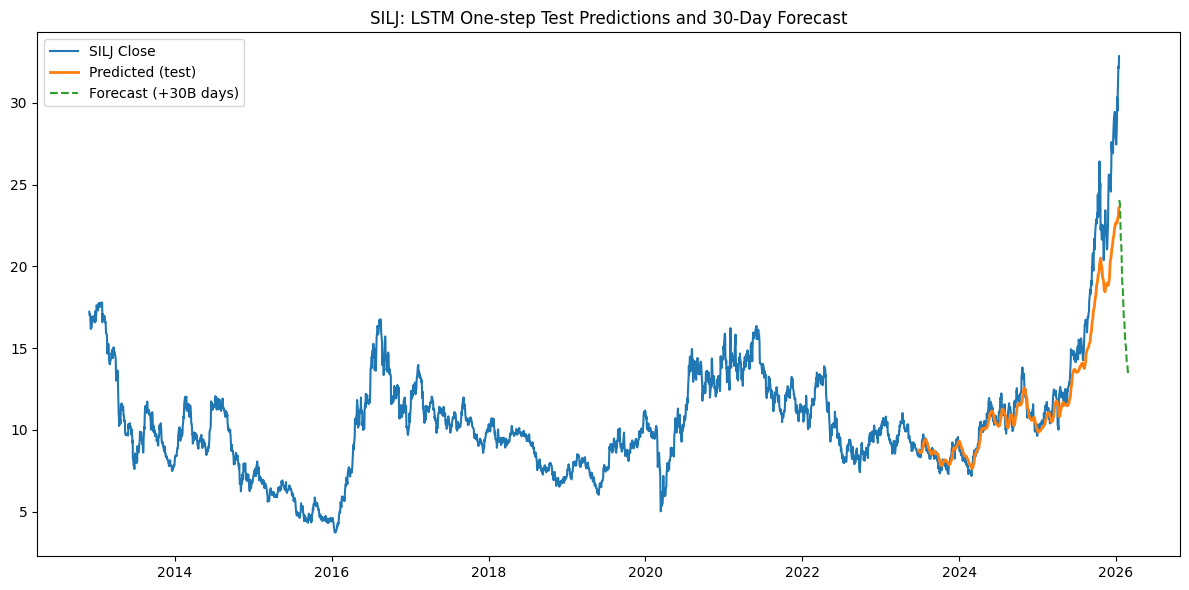

Test RMSE: 1.94


In [ ]:
# Imports
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Configuration
TICKER = "SILJ"
START = "2012-01-01"
END   = "2026-01-16"
TIME_STEP = 100
TRAIN_RATIO = 0.8
FUTURE_STEPS = 30       # forecast 30 business days ahead

# 1) Importing data
df = yf.download(TICKER, start=START, end=END, progress=False)
close = df["Close"].dropna()
values = close.values.reshape(-1, 1).astype(np.float32)

# 2) Scale on train only and create supervised windows
def create_dataset(data, time_step):
    X, y = [], []
    for i in range(len(data) - time_step - 1):
        X.append(data[i:i + time_step, 0])
        y.append(data[i + time_step, 0])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

N = len(values) - TIME_STEP - 1
train_N = int(N * TRAIN_RATIO)

scaler = MinMaxScaler(feature_range=(0, 1))
# Fit on the portion of raw prices that corresponds to training windows
scaler.fit(values[: TIME_STEP + train_N])

scaled_values = scaler.transform(values)
X_all, y_all = create_dataset(scaled_values, TIME_STEP)

# Chronological split
X_train, X_test = X_all[:train_N], X_all[train_N:]
y_train, y_test = y_all[:train_N], y_all[train_N:]

# Coding the AI
X_train = X_train.reshape((X_train.shape[0], TIME_STEP, 1))
X_test  = X_test.reshape((X_test.shape[0],  TIME_STEP, 1))

# 3) Build and train model
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(TIME_STEP, 1)),
    LSTM(64),
    Dense(64, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=25,
    batch_size=64,
    validation_split=0.1,
    shuffle=False,
    callbacks=[es],
    verbose=1
)

# 4) Evaluate and test-set predictions
test_loss = model.evaluate(X_test, y_test, verbose=0)
print("Test Loss (MSE):", test_loss)

pred_test_scaled = model.predict(X_test, verbose=0)
pred_test = scaler.inverse_transform(pred_test_scaled).flatten()

# Align predictions to dates
y_indices = np.arange(TIME_STEP, TIME_STEP + N)
test_indices = y_indices[train_N:]
pred_test_series = pd.Series(pred_test, index=close.index[test_indices])

# 5) Multi-step future forecast
last_window = scaled_values[-TIME_STEP:].reshape(1, TIME_STEP, 1).copy()
future_scaled = []
for _ in range(FUTURE_STEPS):
    next_scaled = model.predict(last_window, verbose=0)[0, 0]
    future_scaled.append(next_scaled)
    last_window = np.append(last_window[:, 1:, :], [[[next_scaled]]], axis=1)

future = scaler.inverse_transform(np.array(future_scaled).reshape(-1, 1)).flatten()

# Create future business-day index
future_index = pd.bdate_range(start=close.index[-1] + pd.Timedelta(days=1), periods=FUTURE_STEPS)
future_series = pd.Series(future, index=future_index)

# 6) Plot graph
plt.figure(figsize=(12, 6))
plt.plot(close.index, close.values, label=f'{TICKER} Close')
plt.plot(pred_test_series.index, pred_test_series.values, label='Predicted (test)', linewidth=2)
plt.plot(future_series.index, future_series.values, label='Forecast (+30B days)', linestyle='--')
plt.title(f'{TICKER}: LSTM One-step Test Predictions and {FUTURE_STEPS}-Day Forecast')
plt.legend()
plt.tight_layout()
plt.show()

# 7) Testing the data
from sklearn.metrics import mean_squared_error
import math
rmse = math.sqrt(mean_squared_error(close.values[test_indices], pred_test))
print(f"Test RMSE: {rmse:.2f}")
